# Notebook 01 - French power price seasonality

This notebook prepares the electricity price data used by the CARMA checks.

The deterministic seasonality is calibrated on 2024 only, then applied out of sample to 2025. The outputs are kept inside `france/france24vs25/data/seasonality` so this check pipeline is self-contained.


## 1. Setup and price import

The ENTSO-E day-ahead price query covers 2024-2025 with an exclusive end date of `2026-01-01`, so the 2025 validation year is complete.


In [1]:
a=1

In [2]:
%matplotlib inline

from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from dotenv import load_dotenv
from entsoe import EntsoePandasClient
from scipy import stats
from scipy.stats import norm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf

plt.rcParams.update({
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CWD = Path.cwd().resolve()
if (CWD / "france" / "france24vs25").exists():
    PROJECT_ROOT = CWD
    CHECK_DIR = CWD / "france" / "france24vs25"
elif CWD.name == "france24vs25":
    CHECK_DIR = CWD
    PROJECT_ROOT = CWD.parent.parent
else:
    raise FileNotFoundError("Run this notebook from the repo root or from france/france24vs25/.")

load_dotenv(PROJECT_ROOT / ".env")
API_KEY = os.getenv("ENTSOE_API_KEY")
if not API_KEY:
    raise RuntimeError("ENTSOE_API_KEY not found in .env or environment.")

DATA_DIR = CHECK_DIR / "data" / "seasonality"
FIG_DIR = CHECK_DIR / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

ZONE = "FR"
TRAIN_START = pd.Timestamp("2024-01-01", tz="UTC")
TRAIN_END = pd.Timestamp("2025-01-01", tz="UTC")
TEST_START = TRAIN_END
TEST_END = pd.Timestamp("2026-01-01", tz="UTC")
DELTA_SHIFT = 1000.0

print(f"Project root : {PROJECT_ROOT}")
print(f"Output data  : {DATA_DIR}")
print(f"Train period : {TRAIN_START} <= t < {TRAIN_END}")
print(f"Test period  : {TEST_START} <= t < {TEST_END}")


Project root : C:\Users\gabri\Documents\quant-projects\FR_carma_quanto
Output data  : C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\data\seasonality
Train period : 2024-01-01 00:00:00+00:00 <= t < 2025-01-01 00:00:00+00:00
Test period  : 2025-01-01 00:00:00+00:00 <= t < 2026-01-01 00:00:00+00:00


In [3]:
client = EntsoePandasClient(api_key=API_KEY)

prices = client.query_day_ahead_prices(
    ZONE,
    start=TRAIN_START,
    end=TEST_END,
)

prices_df = prices.to_frame(name="price_eur_mwh")
prices_df.index.name = "datetime"
prices_df = prices_df.tz_convert("UTC").sort_index()

price_raw_all = (
    prices_df["price_eur_mwh"]
    .asfreq("h")
    .interpolate(method="linear")
)
price_raw_all = price_raw_all.loc[(price_raw_all.index >= TRAIN_START) & (price_raw_all.index < TEST_END)]

expected_hours = int((TEST_END - TRAIN_START) / pd.Timedelta(hours=1))
if len(price_raw_all) != expected_hours:
    print(f"Warning: expected {expected_hours:,} hourly prices, got {len(price_raw_all):,}.")

price_all = np.log(price_raw_all + DELTA_SHIFT).rename("log_price")
train_mask = (price_all.index >= TRAIN_START) & (price_all.index < TRAIN_END)
test_mask = (price_all.index >= TEST_START) & (price_all.index < TEST_END)

price_train = price_all.loc[train_mask]
price_test = price_all.loc[test_mask]
price_raw_train = price_raw_all.loc[train_mask]
price_raw_test = price_raw_all.loc[test_mask]

print(f"Loaded {len(price_all):,} hourly prices from {price_all.index.min()} to {price_all.index.max()}")
print(f"Train hours: {len(price_train):,}; test hours: {len(price_test):,}")
print(f"Raw price min/max: {price_raw_all.min():.2f} / {price_raw_all.max():.2f} EUR/MWh")
display(price_raw_all.to_frame("price_eur_mwh").head())


Loaded 17,544 hourly prices from 2024-01-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00
Train hours: 8,784; test hours: 8,760
Raw price min/max: -118.01 / 473.28 EUR/MWh


,price_eur_mwh
datetime,
2024-01-01 00:00:00+00:00,0.01
2024-01-01 01:00:00+00:00,0.00
2024-01-01 02:00:00+00:00,-0.01
2024-01-01 03:00:00+00:00,-0.03
2024-01-01 04:00:00+00:00,-0.02


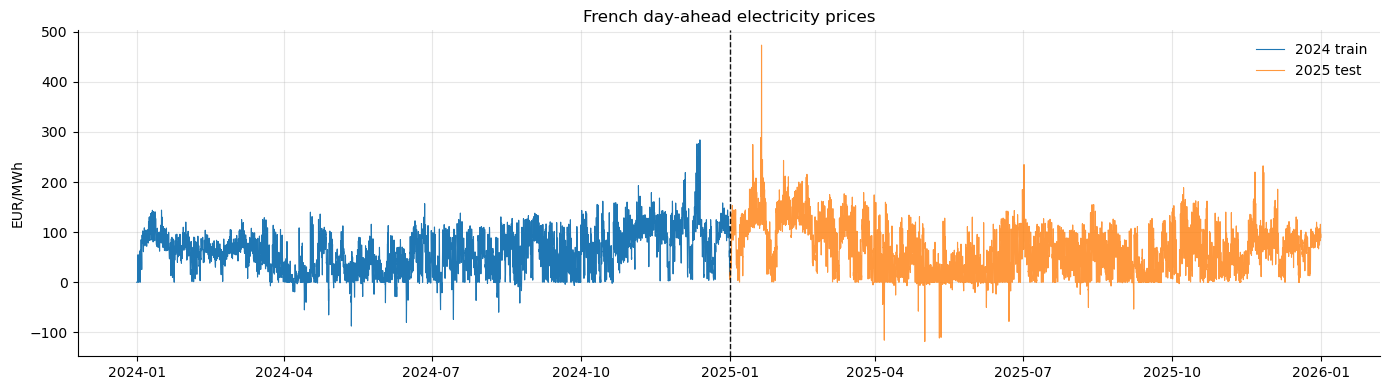

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(price_raw_train.index, price_raw_train, lw=0.8, label="2024 train")
ax.plot(price_raw_test.index, price_raw_test, lw=0.8, label="2025 test", alpha=0.8)
ax.axvline(TEST_START, color="#111111", lw=1.0, ls="--")
ax.set_title("French day-ahead electricity prices")
ax.set_ylabel("EUR/MWh")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 2. Factor-to-day on 2024

The intra-day factor uses 20 profile classes: weekday months 1-12, then Saturday/Sunday split by four seasonal buckets. Each class receives an hourly profile fitted on 2024 only.


In [5]:
def assign_profile_class(index):
    out = np.zeros(len(index), dtype=int)
    for i, (month, dow) in enumerate(zip(index.month, index.dayofweek)):
        if dow <= 4:
            out[i] = month
        elif dow == 5:
            if month in [1, 2, 12]:
                out[i] = 13
            elif month in [3, 4, 5]:
                out[i] = 14
            elif month in [6, 7, 8]:
                out[i] = 15
            else:
                out[i] = 16
        else:
            if month in [1, 2, 12]:
                out[i] = 17
            elif month in [3, 4, 5]:
                out[i] = 18
            elif month in [6, 7, 8]:
                out[i] = 19
            else:
                out[i] = 20
    return out


def hourly_design(index):
    hour_dummies = pd.get_dummies(index.hour, drop_first=True).astype(float)
    return np.column_stack([np.ones(len(index)), hour_dummies.to_numpy()])


def fit_f2d(price):
    idx = price.index
    profile_class = assign_profile_class(idx)
    X_base = hourly_design(idx)

    f2d_hat = np.zeros(len(idx), dtype=float)
    coeffs_by_class = {}

    for class_id in np.unique(profile_class):
        mask = profile_class == class_id
        X_class = X_base[mask]
        y_class = price[mask].to_numpy(float)
        coeffs, *_ = np.linalg.lstsq(X_class, y_class, rcond=None)
        predicted = X_class @ coeffs
        mean_shape = float(np.mean(predicted))
        f2d_hat[mask] = predicted / mean_shape if mean_shape != 0.0 else 1.0
        coeffs_by_class[int(class_id)] = {
            "coefficients": coeffs.tolist(),
            "mean_shape": mean_shape,
        }

    return pd.Series(f2d_hat, index=idx, name="f2d_hat"), coeffs_by_class


def predict_f2d(index, coeffs_by_class):
    profile_class = assign_profile_class(index)
    X_base = hourly_design(index)
    out = np.ones(len(index), dtype=float)

    for class_id in np.unique(profile_class):
        mask = profile_class == class_id
        params = coeffs_by_class.get(int(class_id))
        if params is None:
            continue
        coeffs = np.asarray(params["coefficients"], dtype=float)
        mean_shape = float(params["mean_shape"])
        predicted = X_base[mask] @ coeffs
        out[mask] = predicted / mean_shape if mean_shape != 0.0 else 1.0

    return pd.Series(out, index=index, name="f2d_hat")


f2d_train, f2d_coeffs_by_class = fit_f2d(price_train)
f2d_test = predict_f2d(price_test.index, f2d_coeffs_by_class)

f2d_summary = pd.Series(assign_profile_class(price_train.index)).value_counts().sort_index()
print("Training observations by profile class:")
print(f2d_summary.to_string())


Training observations by profile class:
1     552
2     504
3     504
4     528
5     552
6     480
7     552
8     528
9     504
10    552
11    504
12    528
13    288
14    312
15    336
16    312
17    312
18    312
19    312
20    312


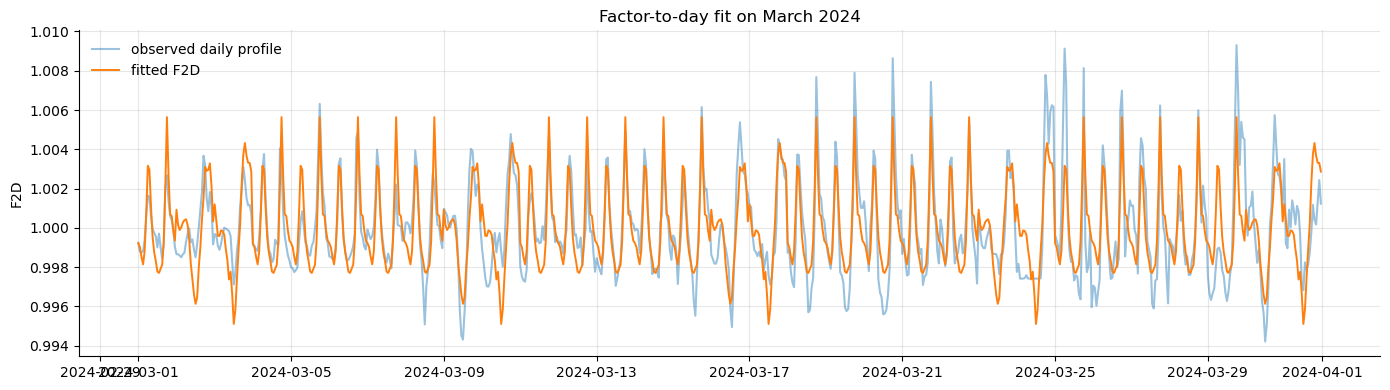

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
zoom = slice("2024-03-01", "2024-03-31")
day_mean = price_train.resample("D").mean()
f2d_observed = price_train / day_mean.reindex(price_train.index.floor("D")).to_numpy(float)
ax.plot(f2d_observed.loc[zoom].index, f2d_observed.loc[zoom], alpha=0.45, label="observed daily profile")
ax.plot(f2d_train.loc[zoom].index, f2d_train.loc[zoom], lw=1.4, label="fitted F2D")
ax.set_title("Factor-to-day fit on March 2024")
ax.set_ylabel("F2D")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 3. Factor-to-year on 2024

The annual factor is fitted from 2024 daily average log-prices using weekday and month dummies, with August split into early and late halves. The fitted 2024 regression is then applied to 2025.


In [7]:
def build_f2y_design(index):
    X = pd.DataFrame(index=index)
    for day_num, label in enumerate(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]):
        X[label] = (X.index.dayofweek == day_num).astype(int)
    for month in range(2, 13):
        if month != 8:
            X[f"Month_{month}"] = (X.index.month == month).astype(int)
    X["Aug_early"] = ((X.index.month == 8) & (X.index.day <= 15)).astype(int)
    X["Aug_late"] = ((X.index.month == 8) & (X.index.day > 15)).astype(int)
    return sm.add_constant(X, has_constant="add")


S_day_train = price_train.resample("D").mean()
yearly_mean_train = S_day_train.groupby(S_day_train.index.year).transform("mean")
y_f2y_train = (S_day_train / yearly_mean_train).dropna()

X_train = build_f2y_design(y_f2y_train.index)
model_f2y = sm.OLS(y_f2y_train, X_train).fit()
f2y_train_daily = model_f2y.fittedvalues.rename("f2y_hat")

S_day_test = price_test.resample("D").mean()
X_test = build_f2y_design(S_day_test.index)
X_test = X_test.reindex(columns=model_f2y.model.exog_names, fill_value=0)
f2y_test_daily = model_f2y.predict(X_test).rename("f2y_hat")

print(model_f2y.summary())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     26.08
Date:                Thu, 18 Jun 2026   Prob (F-statistic):           1.03e-53
Time:                        11:48:31   Log-Likelihood:                 1619.9
No. Observations:                 366   AIC:                            -3202.
Df Residuals:                     347   BIC:                            -3128.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9998      0.001   1514.065      0.0

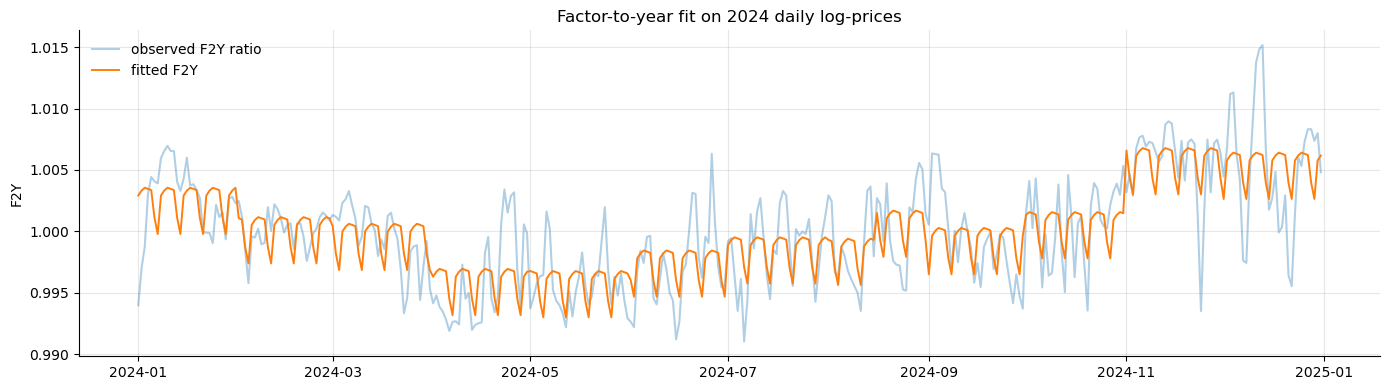

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_f2y_train.index, y_f2y_train, alpha=0.35, label="observed F2Y ratio")
ax.plot(f2y_train_daily.index, f2y_train_daily, lw=1.4, label="fitted F2Y")
ax.set_title("Factor-to-year fit on 2024 daily log-prices")
ax.set_ylabel("F2Y")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 4. Seasonal component and panels

The final deterministic component is `yearly_avg * F2D * F2Y`, with `yearly_avg = mean(log_price)` on the 2024 calibration year. Residuals are computed on 2024 in sample and on 2025 out of sample with the same parameters.


In [9]:
def daily_to_hourly(daily_values, hourly_index):
    return pd.Series(
        daily_values.reindex(hourly_index.floor("D")).to_numpy(float),
        index=hourly_index,
        name=daily_values.name,
    )


f2y_train = daily_to_hourly(f2y_train_daily, price_train.index)
f2y_test = daily_to_hourly(f2y_test_daily, price_test.index)

yearly_avg = float(np.mean(price_train.values))
price_fit_train = (yearly_avg * f2d_train * f2y_train).rename("log_price_seasonal")
price_fit_test = (yearly_avg * f2d_test * f2y_test).rename("log_price_seasonal")

resid_train = (price_train - price_fit_train).rename("log_price_resid")
resid_test = (price_test - price_fit_test).rename("log_price_resid")

train_panel = pd.DataFrame({
    "price_raw": price_raw_train,
    "log_price": price_train,
    "log_price_seasonal": price_fit_train,
    "log_price_resid": resid_train,
})
train_panel["split"] = "train_2024"
train_panel.index.name = "datetime"

test_panel = pd.DataFrame({
    "price_raw": price_raw_test,
    "log_price": price_test,
    "log_price_seasonal": price_fit_test,
    "log_price_resid": resid_test,
})
test_panel["split"] = "test_2025"
test_panel.index.name = "datetime"

panel = pd.concat([train_panel, test_panel]).sort_index()

identity_error = float(np.max(np.abs(panel["log_price"] - panel["log_price_seasonal"] - panel["log_price_resid"])))
print(f"Max |log_price - seasonal - resid| = {identity_error:.3e}")
display(panel.head())
display(panel.tail())


Max |log_price - seasonal - resid| = 0.000e+00


,price_raw,log_price,log_price_seasonal,log_price_resid,split
datetime,,,,,
2024-01-01 00:00:00+00:00,0.01,6.907765,6.964813,-0.057047,train_2024
2024-01-01 01:00:00+00:00,0.00,6.907755,6.962356,-0.054601,train_2024
2024-01-01 02:00:00+00:00,-0.01,6.907745,6.958791,-0.051046,train_2024
2024-01-01 03:00:00+00:00,-0.03,6.907725,6.958206,-0.050481,train_2024
2024-01-01 04:00:00+00:00,-0.02,6.907735,6.964444,-0.056709,train_2024


,price_raw,log_price,log_price_seasonal,log_price_resid,split
datetime,,,,,
2025-12-31 19:00:00+00:00,104.66,7.007293,7.023048,-0.015755,test_2025
2025-12-31 20:00:00+00:00,95.65,6.999103,7.010968,-0.011865,test_2025
2025-12-31 21:00:00+00:00,93.79,6.997404,7.008054,-0.010650,test_2025
2025-12-31 22:00:00+00:00,88.86,6.992887,6.997137,-0.004250,test_2025
2025-12-31 23:00:00+00:00,95.95,6.999377,6.986673,0.012703,test_2025


In [10]:
train_path = DATA_DIR / "price_panel_2024_train.csv"
test_path = DATA_DIR / "price_panel_2025_test.csv"
panel_path = DATA_DIR / "french_price_panel.csv"
compat_path = DATA_DIR / "french_panel.csv"
params_path = DATA_DIR / "price_seasonality_params.json"

train_panel.to_csv(train_path)
test_panel.to_csv(test_path)
panel.to_csv(panel_path)

# Compatibility output for the next notebooks while they are being migrated.
panel.to_csv(compat_path)

params = {
    "zone": ZONE,
    "delta_shift": DELTA_SHIFT,
    "train_start": str(TRAIN_START),
    "train_end_exclusive": str(TRAIN_END),
    "test_start": str(TEST_START),
    "test_end_exclusive": str(TEST_END),
    "yearly_avg_log_price_train": yearly_avg,
    "f2d_coeffs_by_class": f2d_coeffs_by_class,
    "f2y_exog_names": list(model_f2y.model.exog_names),
    "f2y_params": {k: float(v) for k, v in model_f2y.params.items()},
    "outputs": {
        "train_panel": train_path.name,
        "test_panel": test_path.name,
        "full_panel": panel_path.name,
        "compat_panel": compat_path.name,
    },
}
params_path.write_text(json.dumps(params, indent=2))

print(f"Saved: {train_path}")
print(f"Saved: {test_path}")
print(f"Saved: {panel_path}")
print(f"Saved: {compat_path}")
print(f"Saved: {params_path}")


Saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\data\seasonality\price_panel_2024_train.csv
Saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\data\seasonality\price_panel_2025_test.csv
Saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\data\seasonality\french_price_panel.csv
Saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\data\seasonality\french_panel.csv
Saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\data\seasonality\price_seasonality_params.json


## 5. Train/test diagnostics


In [11]:
def residual_metrics(x):
    x = pd.Series(x).dropna()
    return pd.Series({
        "count": int(x.count()),
        "mean": float(x.mean()),
        "std": float(x.std(ddof=0)),
        "rmse": float(np.sqrt(np.mean(x.to_numpy() ** 2))),
        "mae": float(np.mean(np.abs(x.to_numpy()))),
        "q01": float(x.quantile(0.01)),
        "q05": float(x.quantile(0.05)),
        "median": float(x.quantile(0.50)),
        "q95": float(x.quantile(0.95)),
        "q99": float(x.quantile(0.99)),
        "skew": float(stats.skew(x, bias=False)),
        "excess_kurtosis": float(stats.kurtosis(x, fisher=True, bias=False)),
    })


metrics = pd.DataFrame({
    "train_2024": residual_metrics(resid_train),
    "test_2025": residual_metrics(resid_test),
})
metrics["abs_ratio_test_train"] = metrics["test_2025"].abs() / metrics["train_2024"].abs()

metrics_path = DATA_DIR / "price_residual_train_test_metrics.csv"
metrics.to_csv(metrics_path)
print(metrics.to_string(float_format=lambda v: f"{v:.6e}"))
print(f"Saved: {metrics_path}")


                   train_2024     test_2025  abs_ratio_test_train
count            8.784000e+03  8.760000e+03          9.972678e-01
mean             3.579509e-15  3.077616e-03          8.597873e+11
std              2.374614e-02  3.679698e-02          1.549598e+00
rmse             2.374614e-02  3.692546e-02          1.555009e+00
mae              1.850954e-02  2.906271e-02          1.570147e+00
q01             -5.801909e-02 -8.370280e-02          1.442677e+00
q05             -4.129602e-02 -5.450225e-02          1.319794e+00
median           9.032588e-04 -4.596657e-05          5.088970e-02
q95              3.751676e-02  6.587925e-02          1.755995e+00
q99              5.322750e-02  8.956088e-02          1.682605e+00
skew            -1.085349e-01  1.832734e-01          1.688612e+00
excess_kurtosis  5.433237e-01  5.324401e-01          9.799685e-01
Saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\data\seasonality\price_residual_train_test_metrics.csv


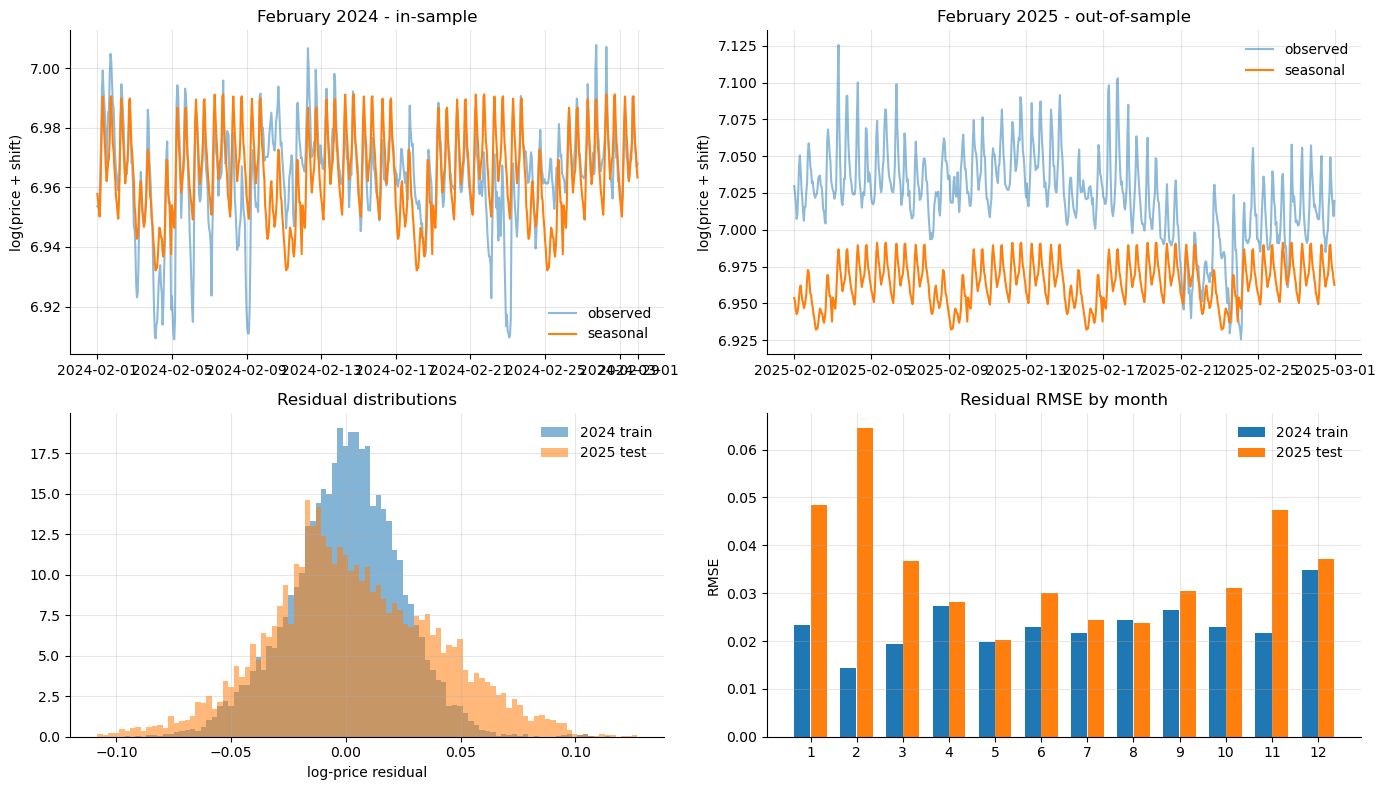

Saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\figures\price_seasonality_train_test_diagnostics.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

zoom_train = slice("2024-02-01", "2024-02-29 23:00")
zoom_test = slice("2025-02-01", "2025-02-28 23:00")

axes[0, 0].plot(price_train.loc[zoom_train].index, price_train.loc[zoom_train], alpha=0.5, label="observed")
axes[0, 0].plot(price_fit_train.loc[zoom_train].index, price_fit_train.loc[zoom_train], lw=1.5, label="seasonal")
axes[0, 0].set_title("February 2024 - in-sample")
axes[0, 0].set_ylabel("log(price + shift)")
axes[0, 0].legend(frameon=False)

axes[0, 1].plot(price_test.loc[zoom_test].index, price_test.loc[zoom_test], alpha=0.5, label="observed")
axes[0, 1].plot(price_fit_test.loc[zoom_test].index, price_fit_test.loc[zoom_test], lw=1.5, label="seasonal")
axes[0, 1].set_title("February 2025 - out-of-sample")
axes[0, 1].set_ylabel("log(price + shift)")
axes[0, 1].legend(frameon=False)

bins = np.linspace(
    min(resid_train.quantile(0.001), resid_test.quantile(0.001)),
    max(resid_train.quantile(0.999), resid_test.quantile(0.999)),
    100,
)
axes[1, 0].hist(resid_train, bins=bins, density=True, alpha=0.55, label="2024 train")
axes[1, 0].hist(resid_test, bins=bins, density=True, alpha=0.55, label="2025 test")
axes[1, 0].set_title("Residual distributions")
axes[1, 0].set_xlabel("log-price residual")
axes[1, 0].legend(frameon=False)

rmse_train_month = resid_train.groupby(resid_train.index.month).apply(lambda x: np.sqrt(np.mean(x**2)))
rmse_test_month = resid_test.groupby(resid_test.index.month).apply(lambda x: np.sqrt(np.mean(x**2)))
months = np.arange(1, 13)
axes[1, 1].bar(months - 0.18, rmse_train_month.reindex(months), width=0.35, label="2024 train")
axes[1, 1].bar(months + 0.18, rmse_test_month.reindex(months), width=0.35, label="2025 test")
axes[1, 1].set_xticks(months)
axes[1, 1].set_title("Residual RMSE by month")
axes[1, 1].set_ylabel("RMSE")
axes[1, 1].legend(frameon=False)

plt.tight_layout()
fig_path = FIG_DIR / "price_seasonality_train_test_diagnostics.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


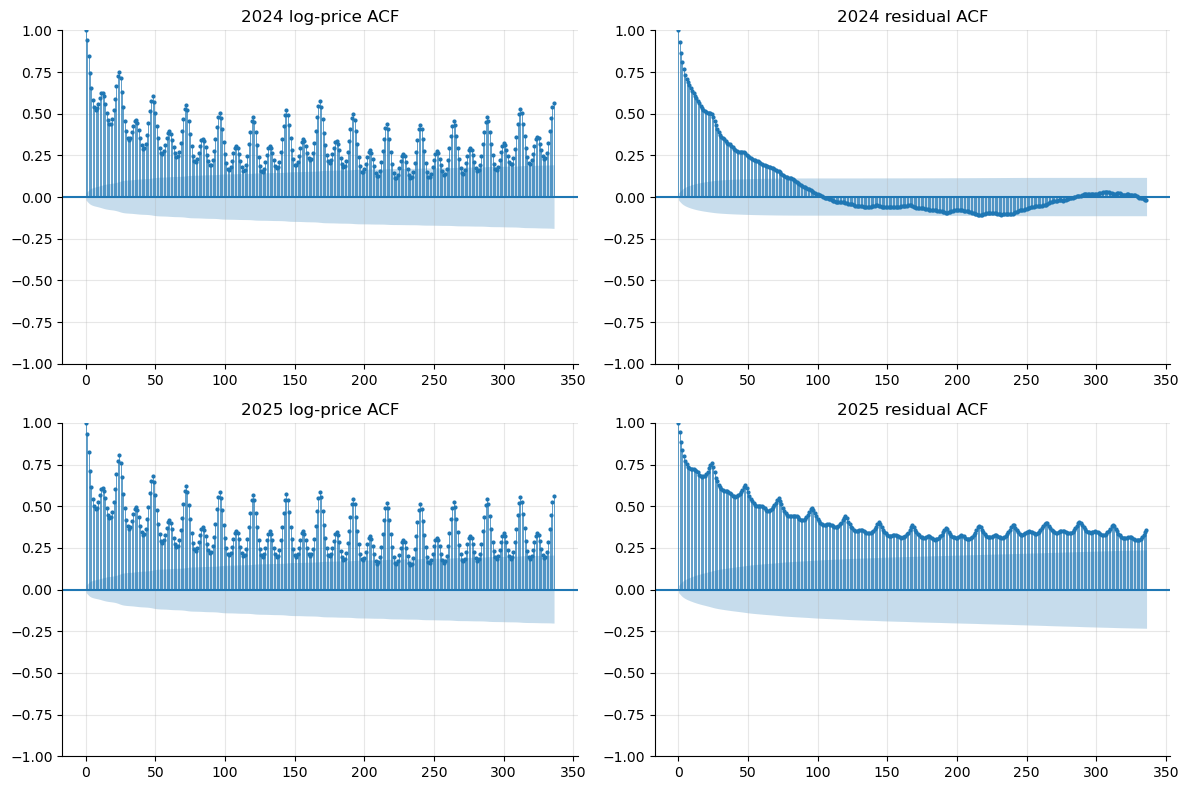

Saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\figures\price_residual_acf_train_test.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(price_train, lags=336, ax=axes[0, 0], vlines_kwargs={"linewidth": 0.5}, markersize=2)
axes[0, 0].set_title("2024 log-price ACF")

plot_acf(resid_train, lags=336, ax=axes[0, 1], vlines_kwargs={"linewidth": 0.5}, markersize=2)
axes[0, 1].set_title("2024 residual ACF")

plot_acf(price_test, lags=336, ax=axes[1, 0], vlines_kwargs={"linewidth": 0.5}, markersize=2)
axes[1, 0].set_title("2025 log-price ACF")

plot_acf(resid_test, lags=336, ax=axes[1, 1], vlines_kwargs={"linewidth": 0.5}, markersize=2)
axes[1, 1].set_title("2025 residual ACF")

plt.tight_layout()
fig_path = FIG_DIR / "price_residual_acf_train_test.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


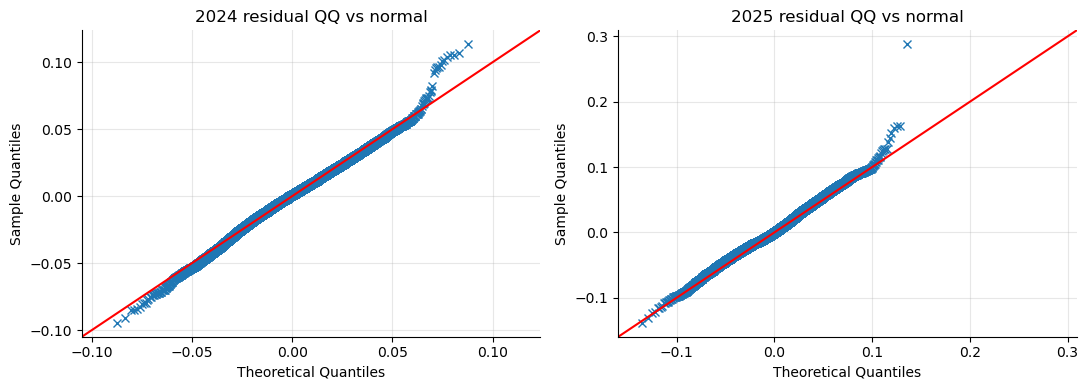

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

qqplot(resid_train, dist=norm, loc=0, scale=resid_train.std(ddof=0), line="45", marker="x", ax=axes[0])
axes[0].set_title("2024 residual QQ vs normal")

qqplot(resid_test, dist=norm, loc=0, scale=resid_test.std(ddof=0), line="45", marker="x", ax=axes[1])
axes[1].set_title("2025 residual QQ vs normal")

plt.tight_layout()
plt.show()
